# Data Loading & Formatting

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd
import seaborn as sns
import sqlite3
import numpy as np
from scipy.stats import rankdata, norm, mannwhitneyu, fisher_exact
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.count_model import ZeroInflatedPoisson
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm

In [3]:
# file paths
DB_PATH = 'human_genome.db' # also needs to be changed in main.py if not this path
GERMLINE_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_germline_high_confidence.parquet'
SOMATIC_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_AMP_HDEL.parquet'
SPLICING_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/fraser_aggregated_outliers_variants.parquet'
EXPRESSION_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/outrider_or_variants_predisppadjust_cnv.parquet'
PROTEIN_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/protrider_pr_variants_predisppadjust_cnv.parquet'


SMALL_VARIANTS_PATH = '/s/project/cancer_pred/MASTER/final_res/splicosome_variants.parquet'

In [4]:
SAMPLE_ID = 'random_id'
splicing = pd.read_parquet(SPLICING_DATA_PATH)

In [5]:
small_var = pd.read_parquet(SMALL_VARIANTS_PATH)

In [6]:
small_var.head()

,Gene,random_id,n_germline_splicing_variant,n_somatic_splicing_variant
0,ENSG00000003756,AHY8852,1.0,0.0
1,ENSG00000003756,BRI3662,0.0,1.0
2,ENSG00000003756,CFD2833,1.0,0.0
3,ENSG00000003756,CXI8998,1.0,0.0
4,ENSG00000003756,DCU0059,1.0,0.0


# Mannwhitneyu + GLM (no somatic/ germline separation)

In [7]:
small_var['total_splicing_vars'] = small_var['n_germline_splicing_variant'] + small_var['n_somatic_splicing_variant']
carriers = small_var[small_var['total_splicing_vars'] > 0][SAMPLE_ID].unique()

all_ids = splicing[SAMPLE_ID].unique()
outlier_burden = splicing.groupby(SAMPLE_ID).size().reindex(all_ids, fill_value=0)
outlier_burden = outlier_burden.reset_index(name='burden')

outlier_burden['is_carrier'] = outlier_burden[SAMPLE_ID].isin(carriers).astype(int)

In [8]:
carrier_burden = outlier_burden[outlier_burden['is_carrier'] == 1]['burden']
non_carrier_burden = outlier_burden[outlier_burden['is_carrier'] == 0]['burden']

stat, p_val = mannwhitneyu(carrier_burden, non_carrier_burden, alternative='greater')

In [9]:
p_val

np.float64(0.02054607809074802)

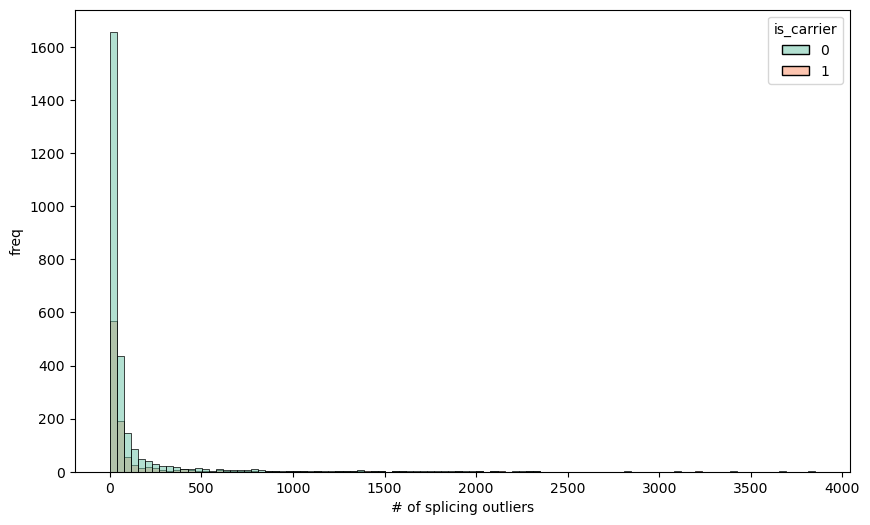

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=outlier_burden, x='burden', hue='is_carrier', bins=100, palette="Set2")
plt.xlabel("# of splicing outliers")
plt.ylabel("freq")
plt.show()

In [11]:
outlier_burden['burden'] = outlier_burden['burden'].astype(int)

model = smf.glm(formula='burden ~ is_carrier', 
                data=outlier_burden, 
                family=sm.families.NegativeBinomial()).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 burden   No. Observations:                 3655
Model:                            GLM   Df Residuals:                     3653
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20937.
Date:                Tue, 14 Jul 2026   Deviance:                       8651.4
Time:                        17:56:19   Pearson chi2:                 2.46e+04
No. Iterations:                     6   Pseudo R-squ. (CS):          8.789e-05
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7181      0.019    243.120      0.0

/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


# Separate somatic & germline analysis

In [12]:
germline = pd.read_parquet(GERMLINE_DATA_PATH)
somatic = pd.read_parquet(SOMATIC_DATA_PATH)

In [13]:
germline_carriers = small_var[small_var['n_germline_splicing_variant'] > 0]['random_id'].unique()
somatic_carriers = small_var[small_var['n_somatic_splicing_variant'] > 0]['random_id'].unique()

In [14]:
def test_outlier_burden(carrier_ids, all_sample_ids, outlier_df):
    burden_df = outlier_df.groupby(SAMPLE_ID).size().reindex(all_sample_ids, fill_value=0).reset_index(name='burden')
    burden_df['is_carrier'] = burden_df[SAMPLE_ID].isin(carrier_ids).astype(int)
    
    model = smf.glm(formula='burden ~ is_carrier', 
                    data=burden_df, 
                    family=sm.families.NegativeBinomial()).fit()
    return model

germline_model = test_outlier_burden(germline_carriers, all_ids, splicing)
print("Germline Results:")
print(germline_model.summary())

somatic_model = test_outlier_burden(somatic_carriers, all_ids, splicing)
print("Somatic Results:")
print(somatic_model.summary())

Germline Results:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 burden   No. Observations:                 3655
Model:                            GLM   Df Residuals:                     3653
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20936.
Date:                Tue, 14 Jul 2026   Deviance:                       8651.0
Time:                        17:56:20   Pearson chi2:                 2.46e+04
No. Iterations:                     6   Pseudo R-squ. (CS):          0.0002061
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7167      0.018  

/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


# Gene specific testing

In [15]:
def gene_specific_test(gene, small_var, splicing_df, all_samples):
    carriers = small_var[small_var['Gene'] == gene]['random_id'].unique()
    
    outliers = splicing_df[splicing_df['geneID_short'] == gene]['random_id'].unique()

    carrier_outlier = len(set(carriers) & set(outliers))
    carrier_no_outlier = len(carriers) - carrier_outlier
    non_carrier_outlier = len(set(outliers) - set(carriers))
    non_carrier_no_outlier = len(all_samples) - (carrier_outlier + carrier_no_outlier + non_carrier_outlier)
    
    table = [[carrier_outlier, carrier_no_outlier], 
             [non_carrier_outlier, non_carrier_no_outlier]]
    
    _, p_val = fisher_exact(table, alternative='greater')
    return p_val

In [16]:
unique_genes = small_var['Gene'].unique() #133
gene_pvals = {g: gene_specific_test(g, small_var, splicing, all_ids) for g in unique_genes}

In [17]:
results_df = pd.DataFrame.from_dict(gene_pvals, orient='index', columns=['p_val'])
results_df.index.name = 'Gene'
stats_df = results_df.reset_index()

genes = stats_df[stats_df['p_val'] < 0.05].sort_values('p_val')

In [18]:
genes

,Gene,p_val
109,ENSG00000170860,1.229832e-09
49,ENSG00000116752,3.480692e-07
100,ENSG00000164609,1.086658e-05
68,ENSG00000132792,4.484652e-04
107,ENSG00000169217,1.032159e-03
17,ENSG00000087365,1.259620e-03
120,ENSG00000183258,1.358664e-03
79,ENSG00000142546,1.815548e-03
114,ENSG00000175324,2.188782e-03
93,ENSG00000160799,2.271188e-03


In [19]:
reject, padj, _, _ = multipletests(stats_df['p_val'], method='fdr_bh')
stats_df['padj'] = padj

sig_genes_fdr = stats_df[stats_df['padj'] < 0.05].sort_values('padj')
print(sig_genes_fdr)

                Gene         p_val          padj
109  ENSG00000170860  1.229832e-09  1.635676e-07
49   ENSG00000116752  3.480692e-07  2.314660e-05
100  ENSG00000164609  1.086658e-05  4.817519e-04
68   ENSG00000132792  4.484652e-04  1.491147e-02
107  ENSG00000169217  1.032159e-03  2.581461e-02
120  ENSG00000183258  1.358664e-03  2.581461e-02
17   ENSG00000087365  1.259620e-03  2.581461e-02
79   ENSG00000142546  1.815548e-03  3.018349e-02
93   ENSG00000160799  2.271188e-03  3.020680e-02
114  ENSG00000175324  2.188782e-03  3.020680e-02
129  ENSG00000204560  3.066840e-03  3.708089e-02
65   ENSG00000130332  3.556772e-03  3.942088e-02
118  ENSG00000182872  3.884495e-03  3.974137e-02
58   ENSG00000124562  4.918024e-03  4.672123e-02


In [20]:
carrier_counts = small_var.groupby('Gene')['random_id'].nunique().reset_index()
carrier_counts.columns = ['Gene', 'n_carriers']

stats_df = stats_df.merge(carrier_counts, on='Gene', how='left')

In [21]:
conn = sqlite3.connect(DB_PATH)
query = "SELECT ensembl_gene_id, symbol FROM genes"
gene_mapping = pd.read_sql(query, conn)
conn.close()
gene_mapping['ensembl_gene_id'] = gene_mapping['ensembl_gene_id'].str.split('.').str[0].str.strip()
id_to_symbol = gene_mapping.dropna().set_index('ensembl_gene_id')['symbol'].to_dict()

stats_df['geneID_filtered'] = stats_df['Gene'].astype(str).str.split('.').str[0].str.strip() 
stats_df['geneID_filtered'] = stats_df['geneID_filtered'].map(id_to_symbol).fillna(stats_df['geneID_filtered'])

/scratch/tmp/deben/ipykernel_2866738/3885884898.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


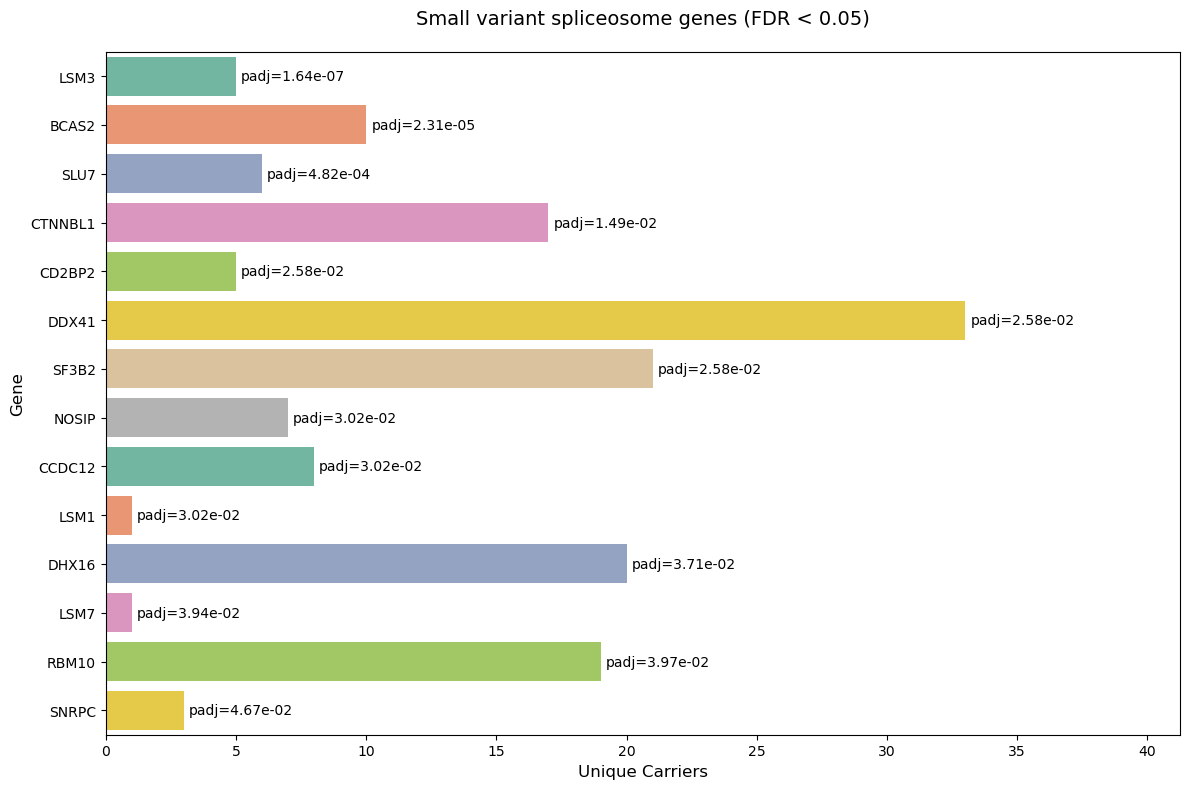

In [22]:
sig_genes_fdr = stats_df[stats_df['padj'] < 0.05].sort_values('padj')

plt.figure(figsize=(12, 8))

sns.barplot(
    data=sig_genes_fdr,
    x='n_carriers',
    y='geneID_filtered',
    palette='Set2'
)

for index, row in sig_genes_fdr.reset_index(drop=True).iterrows():
    x_pos = row['n_carriers']
    padj_text = f"padj={row['padj']:.2e}"
    plt.text(x_pos + 0.2, index, padj_text, va='center', fontsize=10)

plt.title("Small variant spliceosome genes (FDR < 0.05)", fontsize=14, pad=20)
plt.xlabel("Unique Carriers", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.xlim(0, sig_genes_fdr['n_carriers'].max() + (sig_genes_fdr['n_carriers'].max() * 0.25))

plt.tight_layout()
plt.show()

# Gene specific testing: somatic & germline specific analysis

In [23]:
def gene_specific_test_by_origin(gene, small_var, splicing_df, all_samples, origin_col):
    if origin_col == 'germline':
        carriers = small_var[(small_var['Gene'] == gene) & (small_var['n_germline_splicing_variant'] > 0)]['random_id'].unique()
    else:
        carriers = small_var[(small_var['Gene'] == gene) & (small_var['n_somatic_splicing_variant'] > 0)]['random_id'].unique()
    
    outliers = splicing_df[splicing_df['geneID_short'] == gene]['random_id'].unique()

    carrier_outlier = len(set(carriers) & set(outliers))
    carrier_no_outlier = len(carriers) - carrier_outlier
    non_carrier_outlier = len(set(outliers) - set(carriers))
    non_carrier_no_outlier = len(all_samples) - (carrier_outlier + carrier_no_outlier + non_carrier_outlier)
    
    table = [[carrier_outlier, carrier_no_outlier], 
             [non_carrier_outlier, non_carrier_no_outlier]]
    
    _, p_val = fisher_exact(table, alternative='greater')
    return p_val

In [24]:
def gene_spec_test(origin):
    pvals = {g: gene_specific_test_by_origin(g, small_var, splicing, all_ids, origin) for g in unique_genes}
    df = pd.DataFrame.from_dict(pvals, orient='index', columns=['p_val']).reset_index().rename(columns={'index': 'Gene'})
    
    _, padj, _, _ = multipletests(df['p_val'], method='fdr_bh')
    df['padj'] = padj
    
    col_name = 'n_germline_splicing_variant' if origin == 'germline' else 'n_somatic_splicing_variant'
    counts = small_var[small_var[col_name] > 0].groupby('Gene')['random_id'].nunique().reset_index()
    counts.columns = ['Gene', 'n_carriers']
    df = df.merge(counts, on='Gene', how='left').fillna(0)
    
    df['geneID_filtered'] = df['Gene'].astype(str).str.split('.').str[0].str.strip()
    df['geneID_filtered'] = df['geneID_filtered'].map(id_to_symbol).fillna(df['geneID_filtered'])
    
    return df[df['padj'] < 0.05].sort_values('padj')

In [25]:
germline_sig = gene_spec_test('germline')
somatic_sig = gene_spec_test('somatic')

/scratch/tmp/deben/ipykernel_2866738/670506337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


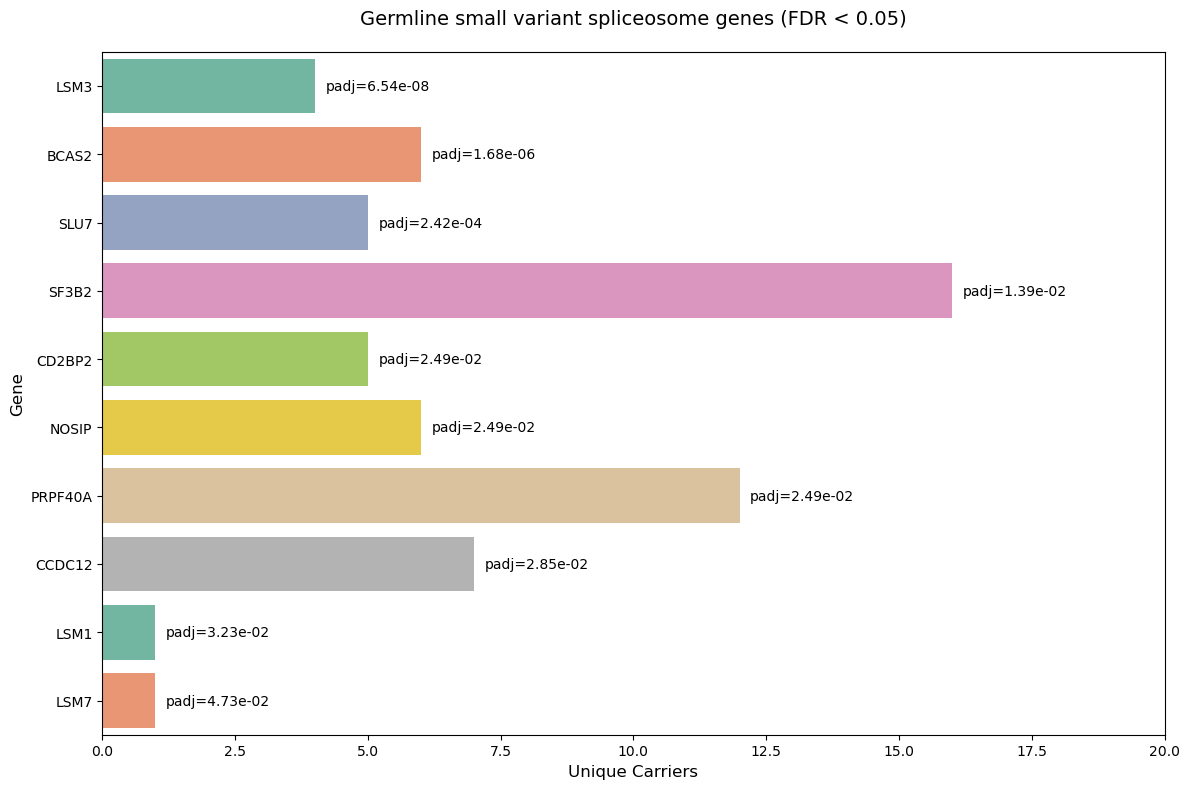

In [26]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=germline_sig,
    x='n_carriers',
    y='geneID_filtered',
    palette='Set2'
)

for index, row in germline_sig.reset_index(drop=True).iterrows():
    x_pos = row['n_carriers']
    padj_text = f"padj={row['padj']:.2e}"
    plt.text(x_pos + 0.2, index, padj_text, va='center', fontsize=10)

plt.title("Germline small variant spliceosome genes (FDR < 0.05)", fontsize=14, pad=20)
plt.xlabel("Unique Carriers", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.xlim(0, germline_sig['n_carriers'].max() + (germline_sig['n_carriers'].max() * 0.25))

plt.tight_layout()
plt.show()

/scratch/tmp/deben/ipykernel_2866738/2708931645.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


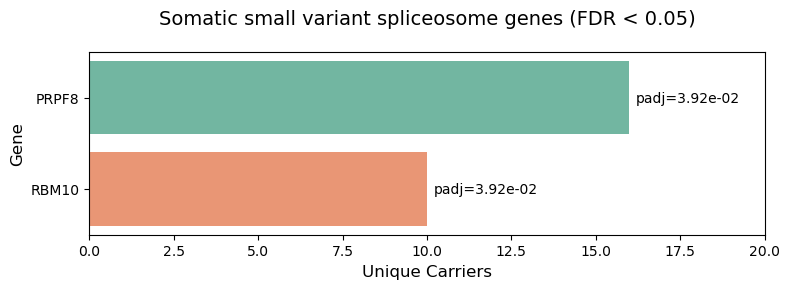

In [27]:
plt.figure(figsize=(8, 3))

sns.barplot(
    data=somatic_sig,
    x='n_carriers',
    y='geneID_filtered',
    palette='Set2'
)

for index, row in somatic_sig.reset_index(drop=True).iterrows():
    x_pos = row['n_carriers']
    padj_text = f"padj={row['padj']:.2e}"
    plt.text(x_pos + 0.2, index, padj_text, va='center', fontsize=10)

plt.title("Somatic small variant spliceosome genes (FDR < 0.05)", fontsize=14, pad=20)
plt.xlabel("Unique Carriers", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.xlim(0, somatic_sig['n_carriers'].max() + (somatic_sig['n_carriers'].max() * 0.25))

plt.tight_layout()
plt.show()

In [28]:
all_carriers = small_var[small_var['total_splicing_vars'] > 0].copy()
all_carriers['origin'] = 'Combined'

germline_only = small_var[small_var['n_germline_splicing_variant'] > 0].copy()
germline_only['origin'] = 'Germline'

somatic_only = small_var[small_var['n_somatic_splicing_variant'] > 0].copy()
somatic_only['origin'] = 'Somatic'

plot_df = pd.concat([all_carriers, germline_only, somatic_only])

plot_df = plot_df.merge(outlier_burden, on=SAMPLE_ID, how='left')

/scratch/tmp/deben/ipykernel_2866738/3071074074.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


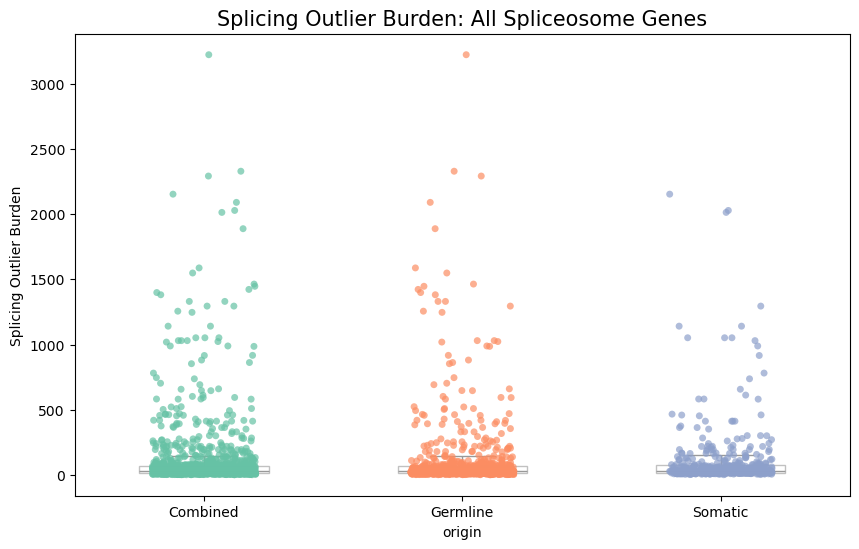

In [30]:
def plot_burden(data, title):
    plt.figure(figsize=(10, 6))
    
    sns.boxplot(
        data=data, x='origin', y='burden', 
        color='white', width=0.5, showfliers=False, boxprops=dict(alpha=0.6)
    )
    
    sns.stripplot(
        data=data, x='origin', y='burden', 
        palette='Set2', jitter=0.2, size=5, alpha=0.7
    )
    
    plt.title(title, fontsize=15)
    plt.ylabel('Splicing Outlier Burden')
    plt.show()

plot_burden(plot_df, "Splicing Outlier Burden: All Spliceosome Genes")

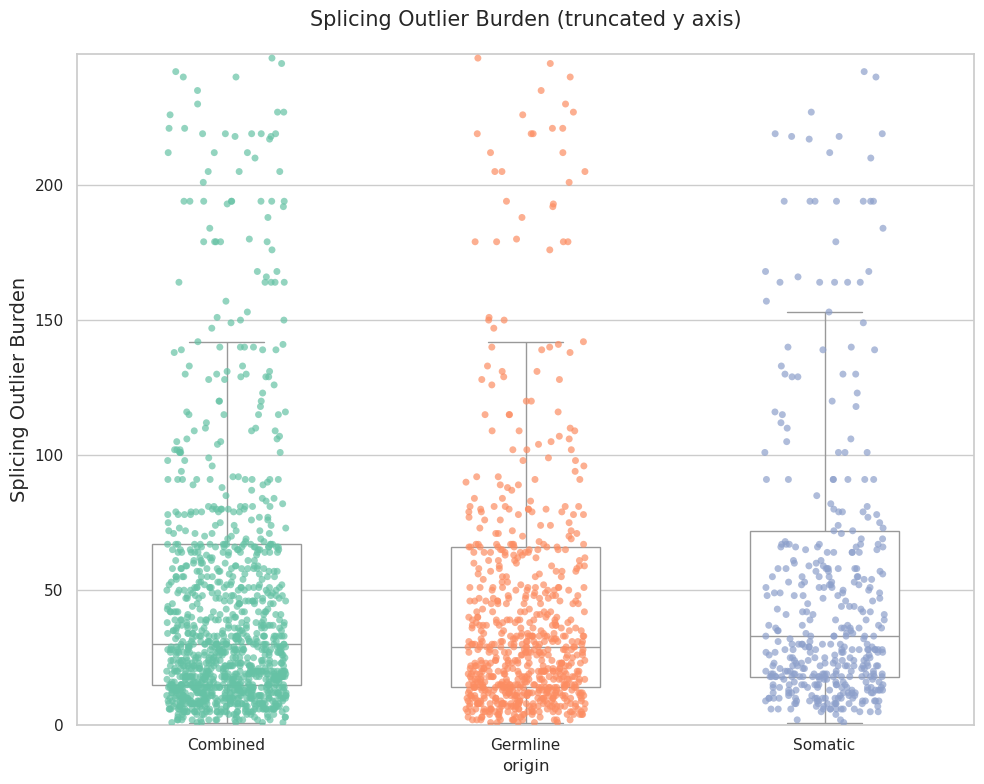

In [32]:
upper_limit = plot_df['burden'].quantile(0.90)

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(data=plot_df, x='origin', y='burden', color='white', width=0.5, showfliers=False)
sns.stripplot(data=plot_df, x='origin', y='burden', hue='origin', palette='Set2', jitter=0.2, size=5, alpha=0.7, legend=False)

plt.ylim(0, upper_limit * 1.1) 
plt.title('Splicing Outlier Burden (truncated y axis)', fontsize=15, pad=20)
plt.ylabel('Splicing Outlier Burden', fontsize=14)
plt.tight_layout()
plt.show()